In [2]:
import numpy as np
import matplotlib.pyplot as plt
from core.IntensityModes import laguerre_gauss as Lg
from core.IntensityModes import hermite_gauss as Hg
from core.PolarizationModes import optical_element, scalar_to_vector
from core.masks import turbulence_mask, turbulence_screen as turb
from core.metrics import intensity as I, power as pwr, phase as phi
from core.propagation import angular_spectrum as aSpec
from core.PolarizationModes import filter_polarizer


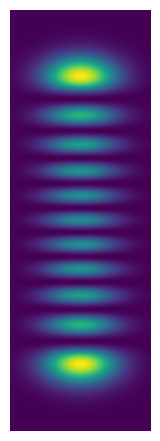

In [3]:
x = np.linspace(-1e-2,1e-2,1000)
y = np.linspace(-1e-2,1e-2,1000)
x,y = np.meshgrid(x,y)

hg = Hg(x,y,10,0,z=5)
hg_prop = Hg(x,y,10,0)

hg_prop = aSpec(hg_prop,x,y,5)
I(hg[200:800,400:600])

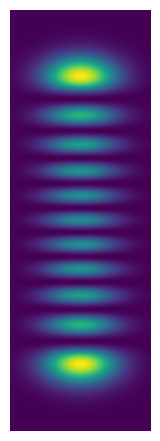

In [4]:
I(hg_prop[200:800,400:600])

power before 1 = 1.0000
power before 2 = 1.0000
power after 1 = 1.0000
power after 2 = 3.749399456654645e-33


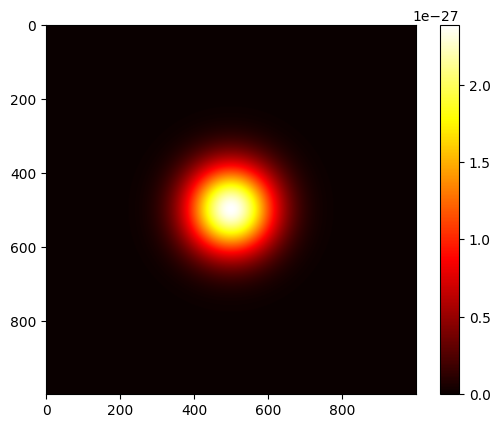

In [35]:
x = np.linspace(-.3e-2,.3e-2,1000)
y = np.linspace(-.3e-2,.3e-2,1000)
x,y = np.meshgrid(x,y)
hg = Hg(x,y,0,0)
print(f'power before 1 = {pwr(x,y,hg):.4f}')
hg = scalar_to_vector(hg)
print(f'power before 2 = {pwr(x,y,hg):.4f}')
hg = optical_element(hg,np.pi/4,'half')
print(f'power after 1 = {pwr(x,y,hg):.4f}')
hg = filter_polarizer(hg,0,'linear')
print(f'power after 2 = {pwr(x,y,hg)}')

plt.imshow(np.linalg.norm(hg,axis=2)**2,'hot')
plt.colorbar()

In [38]:
0.152/18.73*np.pi

0.025495039153531688

# Difração

(np.float64(-0.5), np.float64(999.5), np.float64(999.5), np.float64(-0.5))

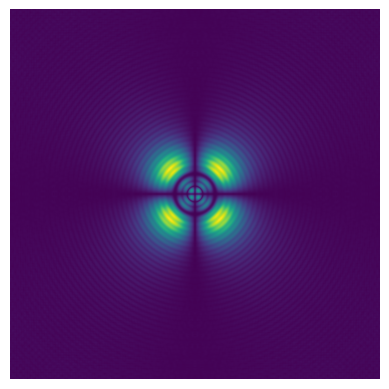

In [11]:
x = np.linspace(-.3e-2,.3e-2,1000)
y = np.linspace(-.3e-2,.3e-2,1000)
x,y = np.meshgrid(x,y)
hg = Hg(x,y,1,1)
#hg = scalar_to_vector(hg)
a = .1e-2
r = np.sqrt(y**2 + x**2)
mask = (r <= .8e-3).astype(float)

E_masked = hg * mask
E_masked = aSpec(E_masked,x,y,0.2)
plt.imshow(np.abs(E_masked))
plt.axis('off')

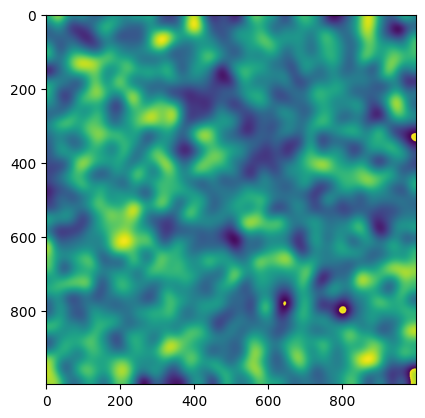

In [ ]:
plt.imshow(phi(turbulence_mask(hg.shape)))

1.0


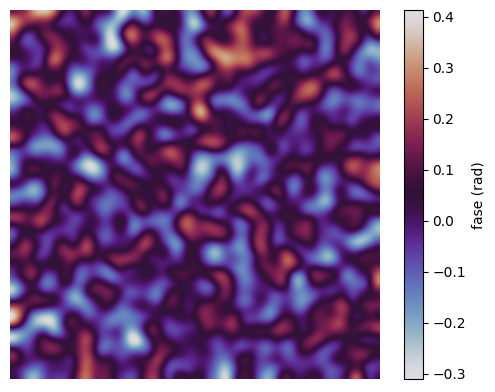

1.7385800291471236e-05


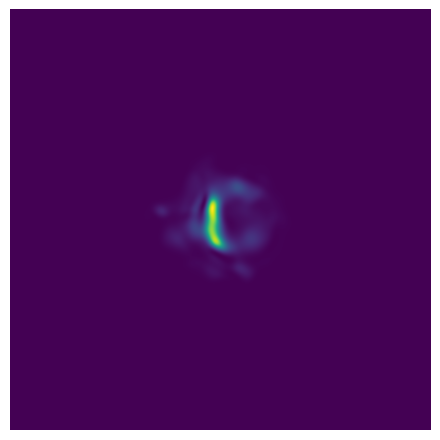

In [31]:
l = 1/2.
n = 1000
x = np.linspace(-l,l,n)
y = np.linspace(-l,l,n)
x,y = np.meshgrid(x,y)
hg = Hg(x,y,0,0,w0=.10)
print(pwr(x,y,hg))
z = 6800
n = 100
strength = .1
corr = 20

plt.imshow(phi(turbulence_mask(hg.shape,strength,corr)),'twilight')
plt.colorbar(label='fase (rad)')
plt.axis(False)
plt.show()

frames = []
masks = []
for i in range(n):
    mask = turbulence_mask(hg.shape,strength,corr)
    masks.append(mask)
    hg = hg * mask
    hg = aSpec(hg, x, y, z/n)
    frames.append(hg)
    
I(hg)
print(pwr(x,y,hg))

2.169599104982958e-12


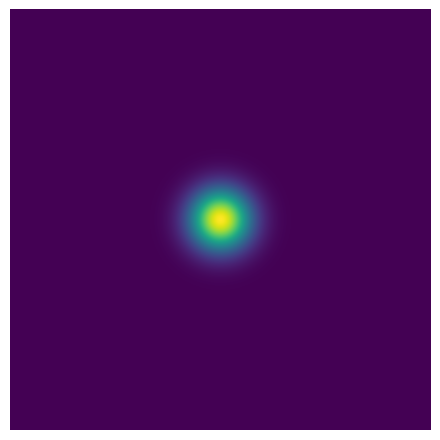

In [28]:
l = 1/2.
n = 1000
x = np.linspace(-l,l,n)
y = np.linspace(-l,l,n)
x,y = np.meshgrid(x,y)
hg = Hg(x,y,0,0,w0=.10)

dx = 2*l/n

r0 = 0.001    # ~ w0  → regime forte
L0 = .0000001     # ~ janela → estruturas grandes
l0 = dx/3    # textura suave
z = 6800

'''
l = 8e-3
x = np.linspace(-l,l,1000)
y = np.linspace(-l,l,1000)
x,y = np.meshgrid(x,y)
hg = Hg(x,y,0,0)

r0 = .06e-4
L0 = l*2
l0 = l
'''
n = 5
mask, phase = turb(x, y, r0, L0, l0)

for i in range(n):
    mask, phase = turb(x, y, r0, L0, l0)
    hg *= mask
    hg = aSpec(hg, x, y, z/n)

print(np.std(phase))
I(hg)


2.5884154770273175e-13


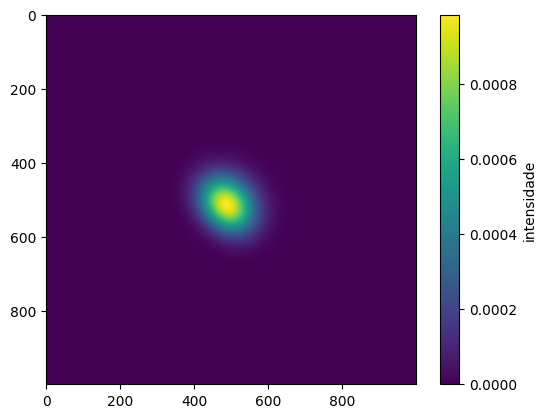

In [ ]:
l = 1/2.
n = 1000
x = np.linspace(-l,l,n)
y = np.linspace(-l,l,n)
x,y = np.meshgrid(x,y)
hg = Hg(x,y,0,0,w0=.10)

'''
r0 = .1e-4
L0 = .81e-2*2
l0 = .81e-2*2/1000*3
z  = 10.0 
'''
'''
r0 = .1e-4     # 3 mm
L0 = l*3  # 5 m
l0 = l # 5e-4 m
z  = 10.0      # 5 m de propagação
'''

dx = 2*l/n

r0 = 0.001   # ~ w0  → regime forte
L0 = 1/2      # ~ janela → estruturas grandes
l0 = 1*dx    # textura suave
z = 6800

print(np.std(phase))
n = 5
frames = []

for i in range(n):
    mask, phase = turb(x, y, r0, L0, l0)
    hg = hg * mask
    hg = aSpec(hg, x, y, z/n)
    frames.append(hg)

plt.imshow(np.abs(hg)**2)
plt.colorbar(label='intensidade')

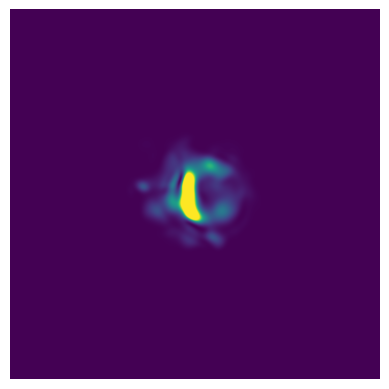

In [ ]:
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
from IPython.display import HTML
fig, ax = plt.subplots()

im = ax.imshow(np.abs(frames[0],dtype=float)**2, cmap='viridis')
ax.axis('off')

def update(i):
    im.set_array(np.abs(frames[i])**2)
    return [im]

ani = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=50,   # ms entre frames
    blit=True
)

HTML(ani.to_jshtml())


In [39]:
ani.save('propagacao.gif', writer='pillow', fps=20)